In [99]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jainaru/world-happiness-report-2024-yearly-updated/World-happiness-report-updated_2024.csv
/kaggle/input/datasets/jainaru/world-happiness-report-2024-yearly-updated/World-happiness-report-2024.csv


## Load Libraries

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Load the dataset from the storage

In [101]:
data = pd.read_csv("/kaggle/input/datasets/jainaru/world-happiness-report-2024-yearly-updated/World-happiness-report-2024.csv", encoding="latin-1")

In [102]:
data.head()

,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


In [103]:
print(f"Total duplicates value in the dataframe",data.duplicated().sum())

Total duplicates value in the dataframe 0


In [104]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  143 non-null    object 
 1   Regional indicator            143 non-null    object 
 2   Ladder score                  143 non-null    float64
 3   upperwhisker                  143 non-null    float64
 4   lowerwhisker                  143 non-null    float64
 5   Log GDP per capita            140 non-null    float64
 6   Social support                140 non-null    float64
 7   Healthy life expectancy       140 non-null    float64
 8   Freedom to make life choices  140 non-null    float64
 9   Generosity                    140 non-null    float64
 10  Perceptions of corruption     140 non-null    float64
 11  Dystopia + residual           140 non-null    float64
dtypes: float64(10), object(2)
memory usage: 13.5+ KB


In [105]:
print("The list of the features that constitutes in the data frame")
data.columns.tolist()

print("The total of null value in the data frame", data.isna().sum())
print("Check the shape of the data frame", data.shape)


The list of the features that constitutes in the data frame
The total of null value in the data frame Country name                    0
Regional indicator              0
Ladder score                    0
upperwhisker                    0
lowerwhisker                    0
Log GDP per capita              3
Social support                  3
Healthy life expectancy         3
Freedom to make life choices    3
Generosity                      3
Perceptions of corruption       3
Dystopia + residual             3
dtype: int64
Check the shape of the data frame (143, 12)


### We have two types of data format in the data frame

**2 Calegorical** 

Regional column and Country name 

**10 Numerical**

And the remains columns are numericals   

In [106]:
data.dropna(inplace=True)
print("After removing the null valus let's check again the shape of the data frame",data.shape)

After removing the null valus let's check again the shape of the data frame (140, 12)


In [107]:
duplicates = data.duplicated().sum()

#data['year'] = data['year'].astype(str)

print(f"The total number of duplicates values in dataframe are {duplicates}")

print("The total size remain:", len(data))

The total number of duplicates values in dataframe are 0
The total size remain: 140


We don't have duplicate value in the dataset, the dataset is clean after removing all the null value.

## List of Region indicator

In [108]:
data['Regional indicator'].unique()

array(['Western Europe', 'Middle East and North Africa',
       'North America and ANZ', 'Latin America and Caribbean',
       'Central and Eastern Europe', 'Southeast Asia', 'East Asia',
       'Commonwealth of Independent States', 'Sub-Saharan Africa',
       'South Asia'], dtype=object)

## List of Countries name

In [109]:
data["Country name"].unique()

array(['Finland', 'Denmark', 'Iceland', 'Sweden', 'Israel', 'Netherlands',
       'Norway', 'Luxembourg', 'Switzerland', 'Australia', 'New Zealand',
       'Costa Rica', 'Kuwait', 'Austria', 'Canada', 'Belgium', 'Ireland',
       'Czechia', 'Lithuania', 'United Kingdom', 'Slovenia',
       'United Arab Emirates', 'United States', 'Germany', 'Mexico',
       'Uruguay', 'France', 'Saudi Arabia', 'Kosovo', 'Singapore',
       'Taiwan Province of China', 'Romania', 'El Salvador', 'Estonia',
       'Poland', 'Spain', 'Serbia', 'Chile', 'Panama', 'Malta', 'Italy',
       'Guatemala', 'Nicaragua', 'Brazil', 'Slovakia', 'Latvia',
       'Uzbekistan', 'Argentina', 'Kazakhstan', 'Cyprus', 'Japan',
       'South Korea', 'Philippines', 'Vietnam', 'Portugal', 'Hungary',
       'Paraguay', 'Thailand', 'Malaysia', 'China', 'Honduras', 'Croatia',
       'Greece', 'Bosnia and Herzegovina', 'Libya', 'Jamaica', 'Peru',
       'Dominican Republic', 'Mauritius', 'Moldova', 'Russia', 'Bolivia',
       'Ecua

## Exoloratory Data Analaysis(EDA)

#### Discriptive Analysis

In [110]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Ladder score,140.0,5.530893,1.181247,1.721,4.63175,5.8005,6.42625,7.741
upperwhisker,140.0,5.644057,1.165108,1.775,4.76225,5.9110,6.51525,7.815
lowerwhisker,140.0,5.417700,1.198051,1.667,4.50375,5.6765,6.33825,7.667
Log GDP per capita,140.0,1.378807,0.425098,0.000,1.07775,1.4315,1.74150,2.141
Social support,140.0,1.134329,0.333317,0.000,0.92175,1.2375,1.38325,1.617
Healthy life expectancy,140.0,0.520886,0.164923,0.000,0.39800,0.5495,0.64850,0.857
Freedom to make life choices,140.0,0.620621,0.162492,0.000,0.52750,0.6410,0.73600,0.863
Generosity,140.0,0.146271,0.073441,0.000,0.09100,0.1365,0.19250,0.401
Perceptions of corruption,140.0,0.154121,0.126238,0.000,0.06875,0.1205,0.19375,0.575
Dystopia + residual,140.0,1.575914,0.537459,-0.073,1.30825,1.6445,1.88175,2.998


Plot distribution of the all numerical column with histoplot method techniques

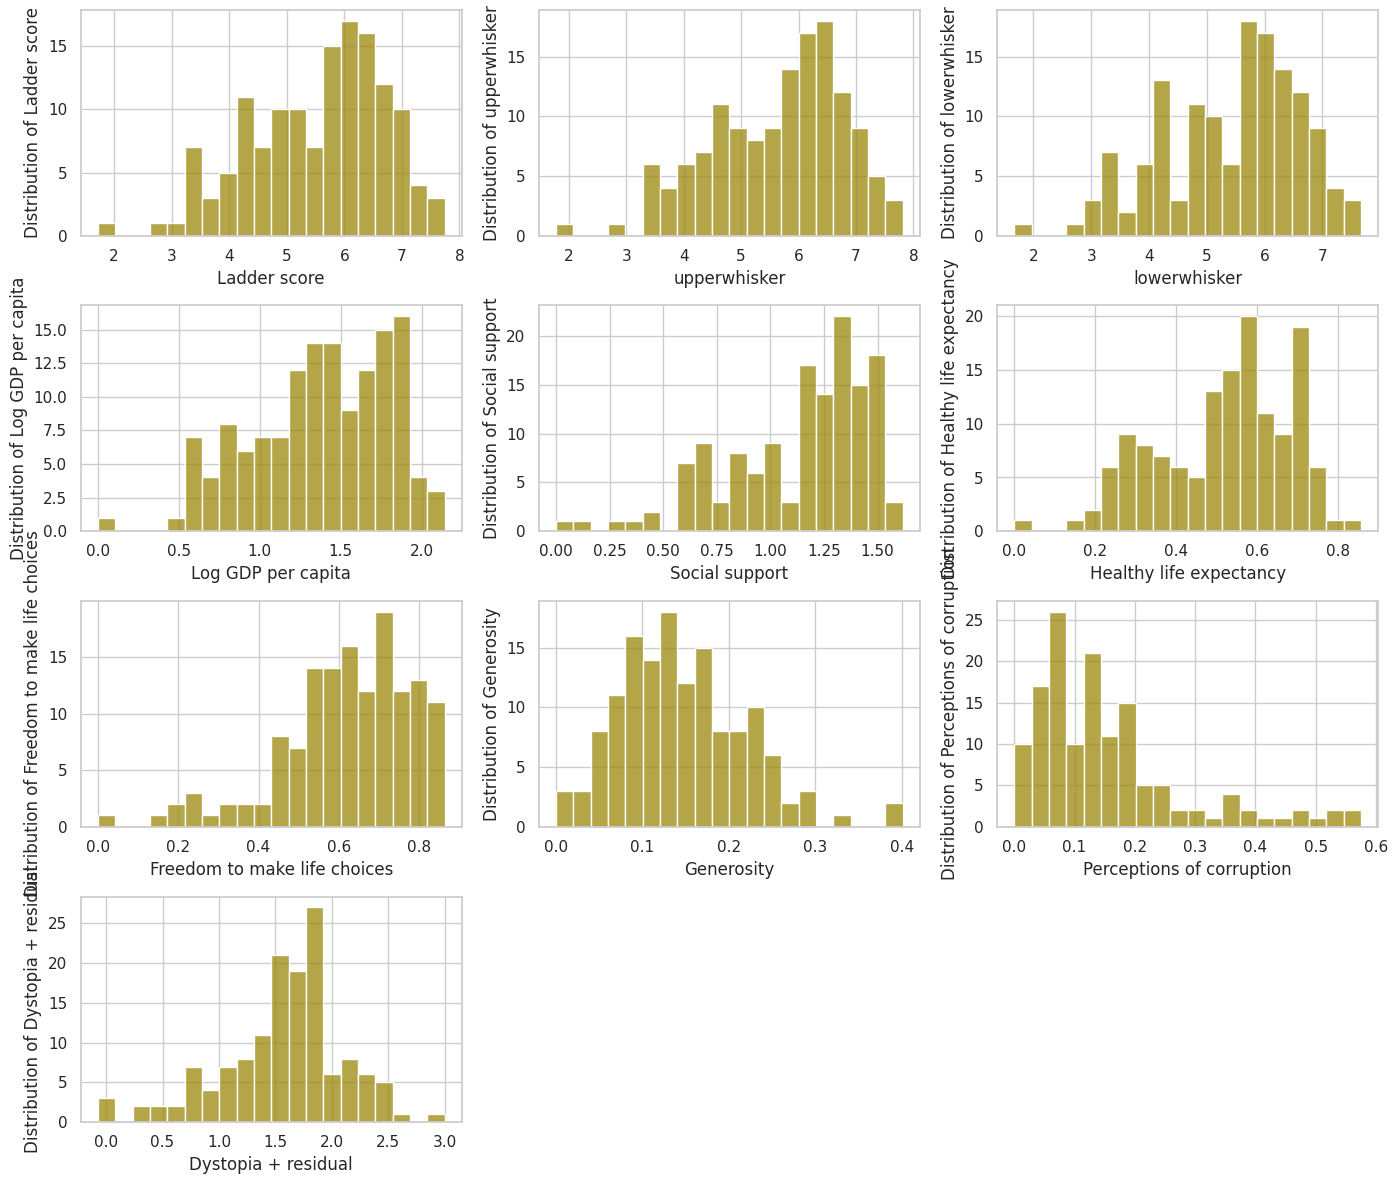

In [111]:
numerical_features = data.select_dtypes(include='number').columns # to get numberic features

#Plot histplot of all numerical columns 
sns.set_style("whitegrid")

plt.figure(figsize=(14,12))

# Loop through numerical features
for i, column in enumerate(numerical_features, start=1):  # Use enumerate to get the index
    plt.subplot(4, 3, i)  # Adjust the number of rows and columns as needed
    sns.histplot(data[column], bins=20, kde=False, color='#9B870C')
    plt.xlabel(column)
    plt.ylabel(f'Distribution of {column}')

plt.tight_layout()
plt.show()

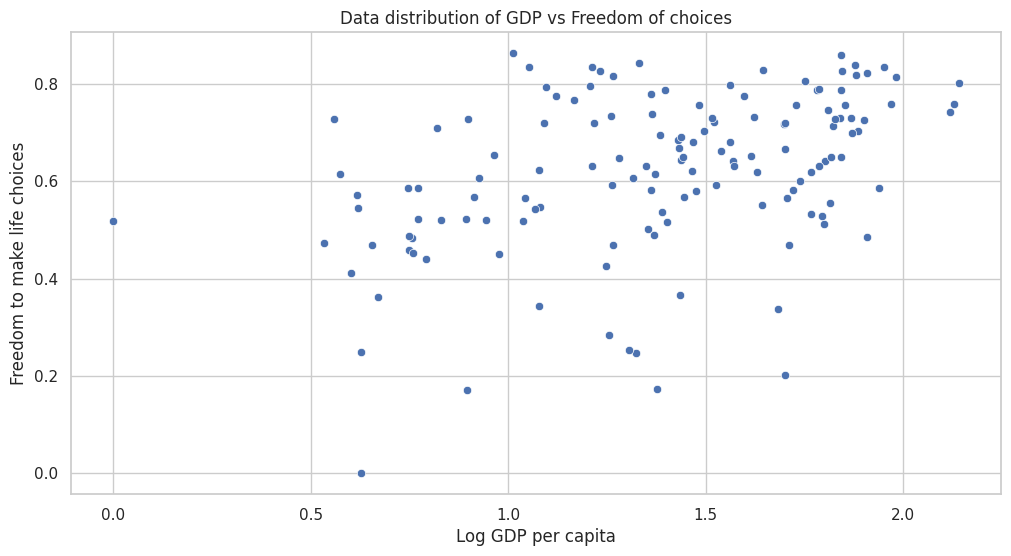

In [112]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=data, x='Log GDP per capita', y='Freedom to make life choices')
plt.title("Data distribution of GDP vs Freedom of choices")
plt.show()

<Figure size 1200x1000 with 0 Axes>

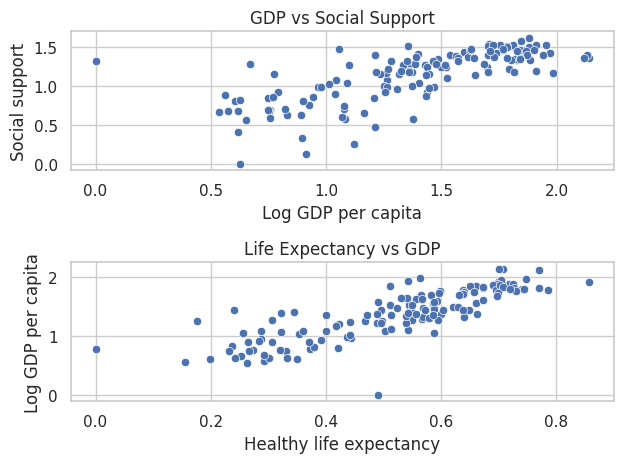

In [113]:
plt.figure(figsize=(12,10))

fig, ax = plt.subplots(2)  # 1 row, 2 columns

# First plot
sns.scatterplot(
    data=data,
    x='Log GDP per capita',
    y='Social support',
    #hue='Regional indicator',
    ax=ax[0]
)
ax[0].set_title("GDP vs Social Support")

# Second plot
sns.scatterplot(
    data=data,
    x='Healthy life expectancy',
    y='Log GDP per capita',
    #hue='Regional indicator',
    ax=ax[1]
)
ax[1].set_title("Life Expectancy vs GDP")

plt.tight_layout()
plt.show()

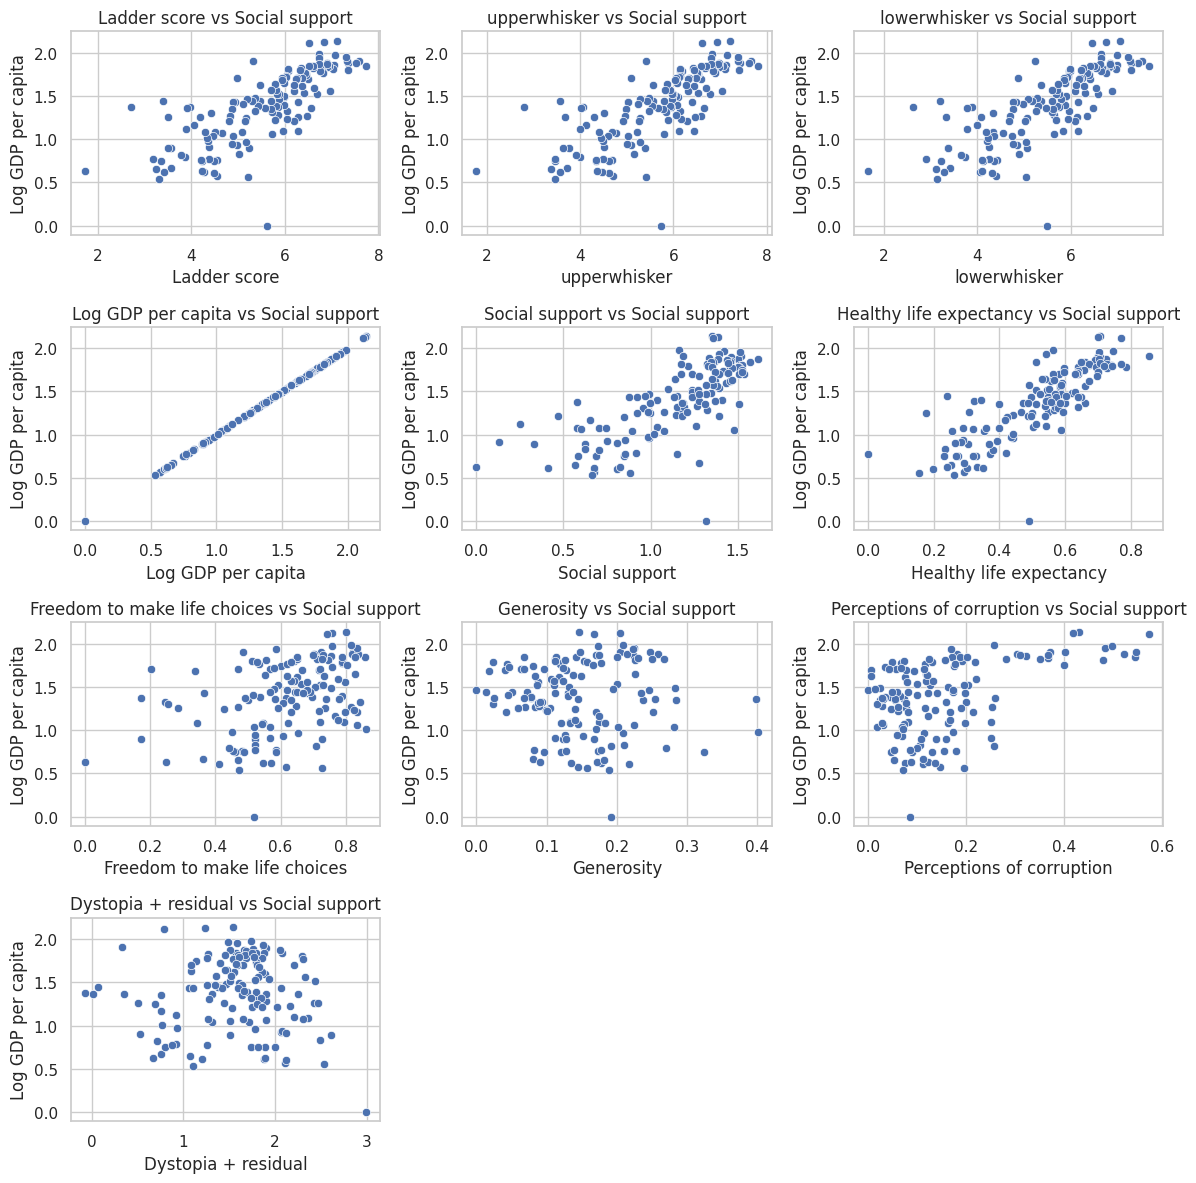

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = data.describe(exclude='object').columns

plt.figure(figsize=(12, 12))

for i, col in enumerate(cols, 1):  # start index at 1
    plt.subplot(4, 3, i)
    sns.scatterplot(data=data, x=col, y='Log GDP per capita')
    plt.title(f"{col} vs Social support")

plt.tight_layout()
plt.show()

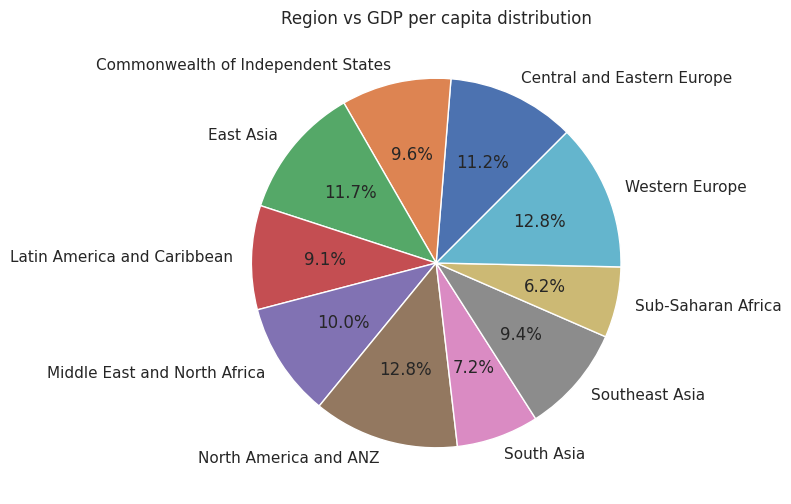

In [115]:
regional_sum = data.groupby('Regional indicator')['Log GDP per capita'].mean().sort_values(ascending=False)

threshold = 0.05 * regional_sum.mean()
regional_sum_filtered = regional_sum.copy()

regional_sum_filtered[regional_sum < threshold] = 0
regional_sum_filtered = regional_sum_filtered.groupby(regional_sum_filtered.index).sum()

plt.figure(figsize=(6,6))
regional_sum_filtered.plot(kind='pie', autopct='%1.1f%%', startangle=45)
plt.title("Region vs GDP per capita distribution")
plt.ylabel("")
plt.show()

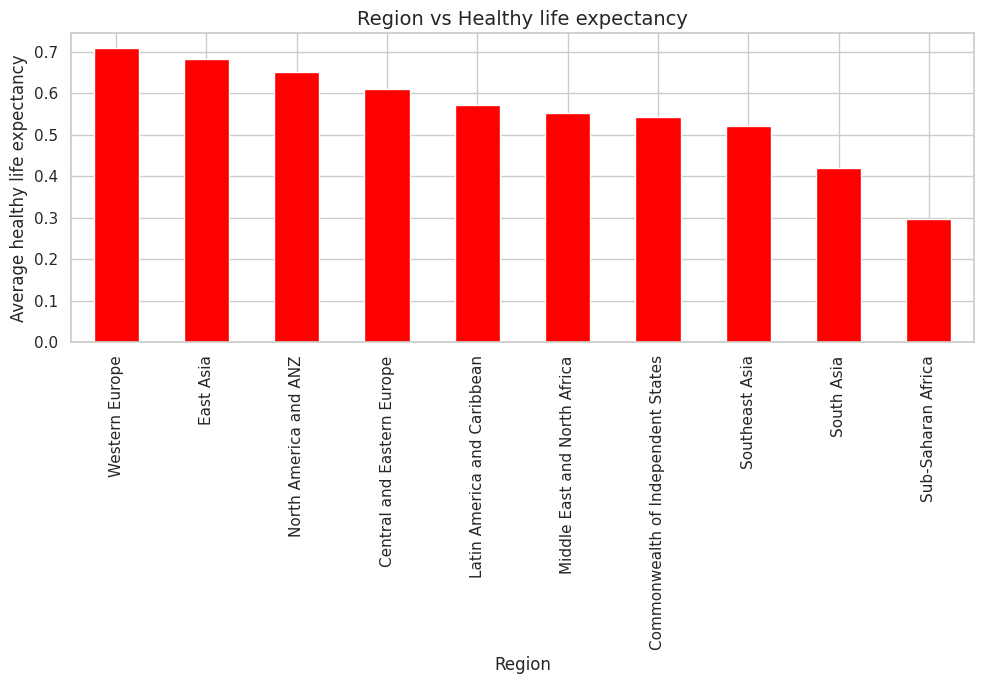

In [116]:
regional_gdp = data.groupby('Regional indicator')['Healthy life expectancy'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,7))

regional_gdp.plot(kind='bar', color='red')

plt.title("Region vs Healthy life expectancy", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Average healthy life expectancy")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

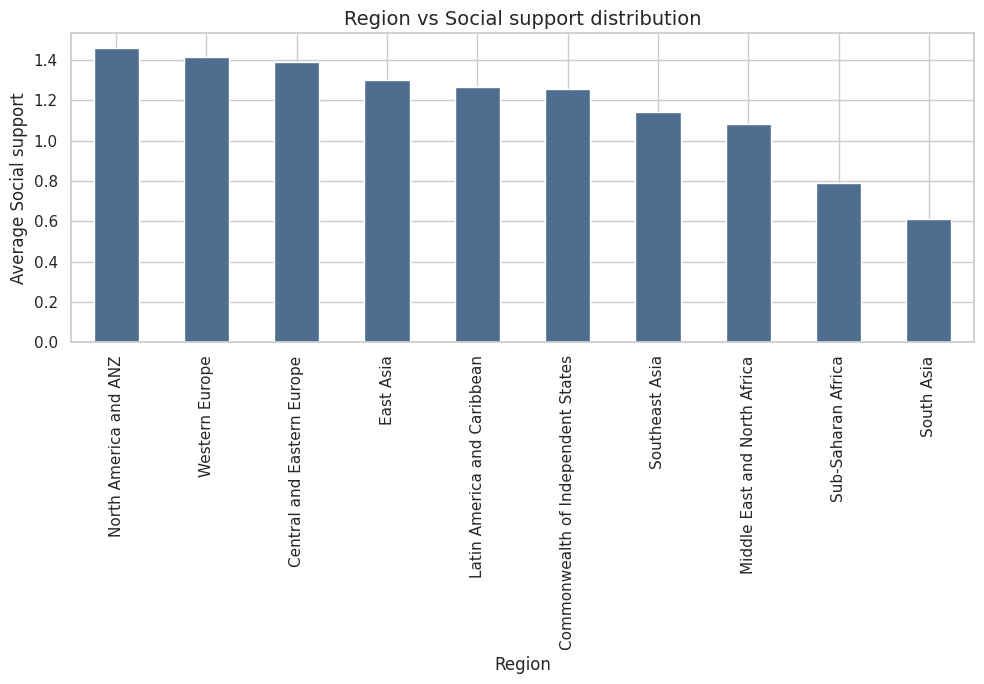

In [117]:
regional_gdp = data.groupby('Regional indicator')['Social support'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,7))

regional_gdp.plot(kind='bar', color='#4f6d8f')

plt.title("Region vs Social support distribution", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Average Social support")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Let Compare Spearman and Peason Correlation methods

__Simple Intuition__
* **Pearson** → “Do these variables move in a straight line together?”
* **Spearman** → “Do these variables move in the same direction overall?”

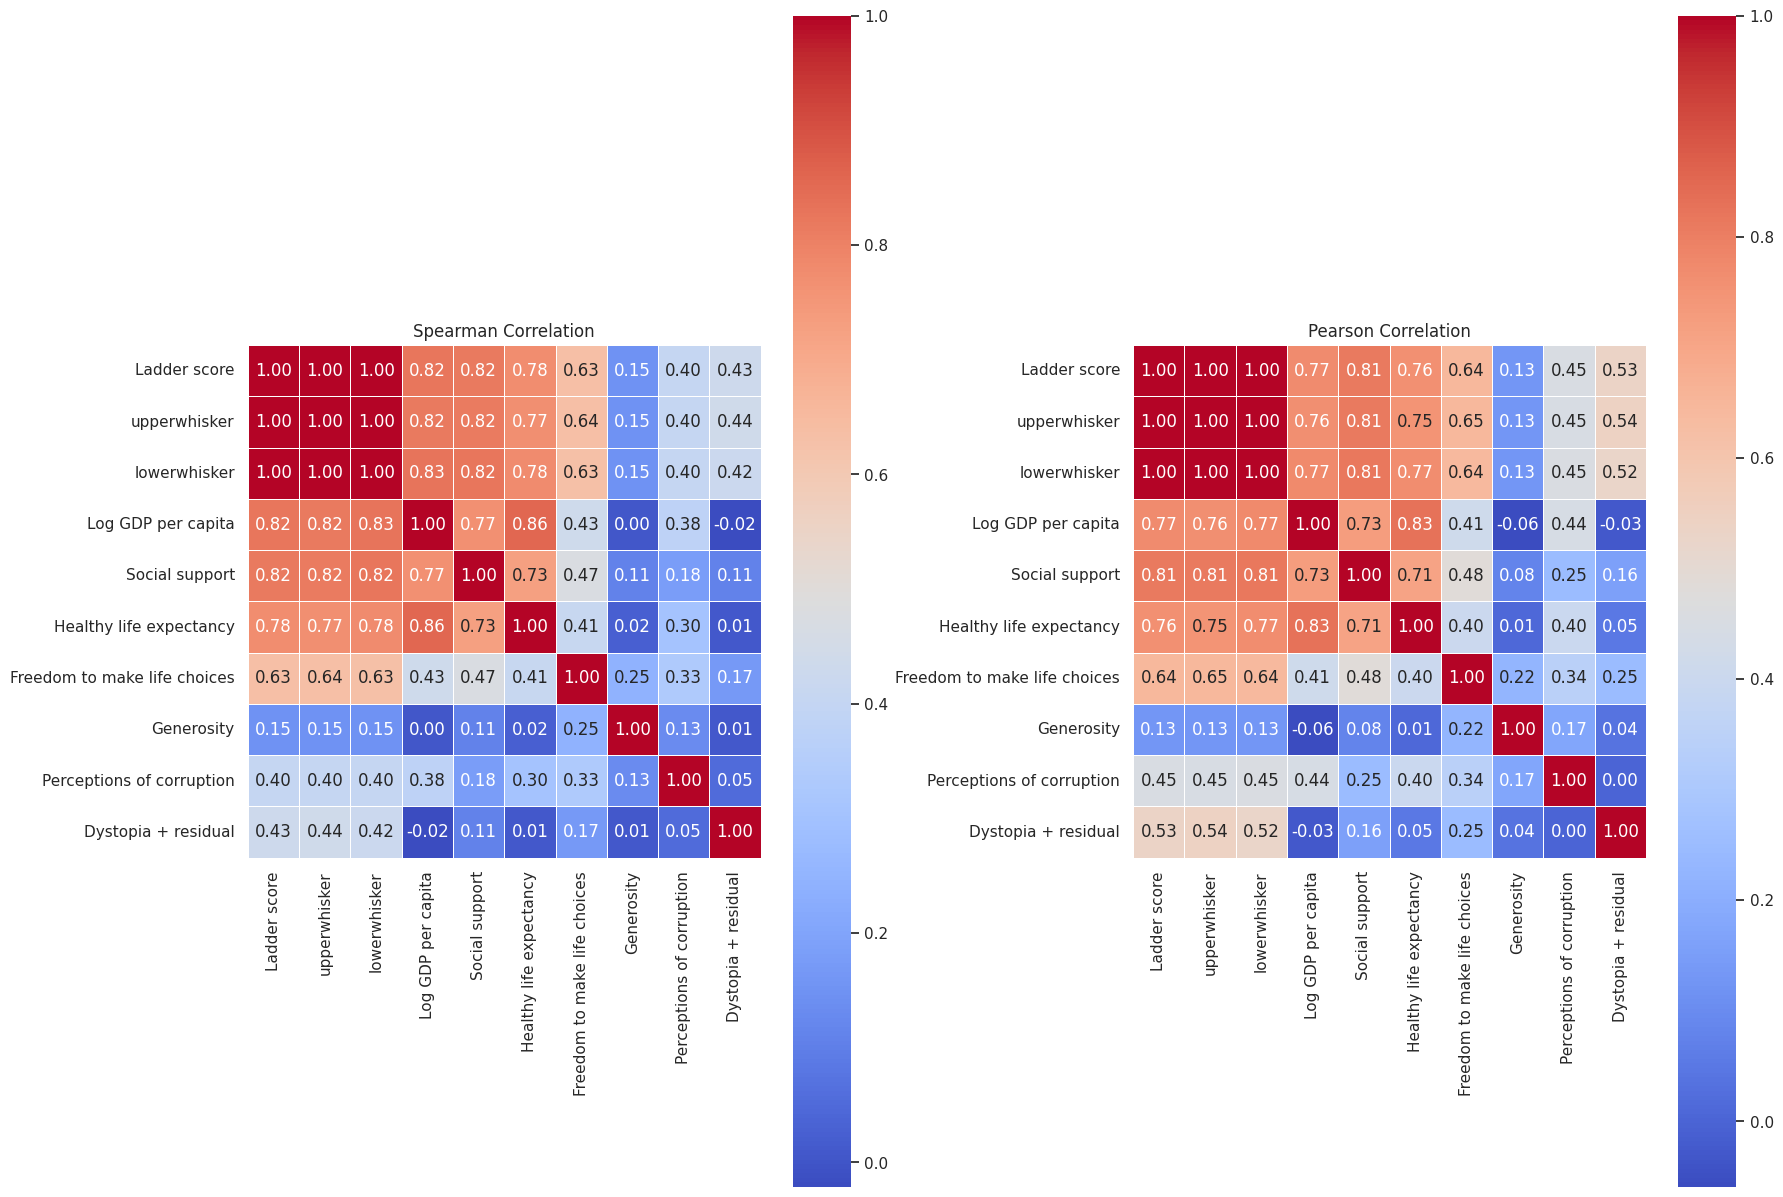

In [118]:
# Select only numerical columns from your DataFrame
corr_spearman = data[numerical_features].corr(method='spearman')
corr_pearson = data[numerical_features].corr(method='pearson')

# Set style for better visuals
sns.set(style="white")

# Create figure with better proportions
fig, ax = plt.subplots(1, 2, figsize=(18, 15))

# Plot heatmap with improvements
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",              # Limit decimals
    cmap="coolwarm",        # Better color contrast
    linewidths=0.5,         # Add spacing between cells
    linecolor='white',
    cbar_kws={"shrink": 0.8},  # Adjust color bar size
    square=True,  
    ax=ax[0]# Make cells square for alignment
)

# Improve title and layout
ax[0].set_title("Spearman Correlation")
ax[0].tick_params(axis='x', rotation=90)
ax[0].tick_params(axis='y', rotation=0)

# Plot heatmap with improvements
sns.heatmap(
    corr_pearson,
    annot=True,
    fmt=".2f",              # Limit decimals
    cmap="coolwarm",        # Better color contrast
    linewidths=0.5,         # Add spacing between cells
    linecolor='white',
    cbar_kws={"shrink": 0.8},  # Adjust color bar size
    square=True,
    ax=ax[1]# Make cells square for alignment
)

# Improve title and layout
ax[1].set_title("Pearson Correlation" )
ax[1].tick_params(axis='x', rotation=90)
ax[1].tick_params(axis='y', rotation=0)

# Ensure everything fits nicely (important for export/print)
# Save for CV / report use
plt.savefig("correlation_comparison.pdf", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

## Here are a few line Explanation of the above:


### General Interpretation

* *“Both Pearson and Spearman correlation matrices show consistent relationships among variables, indicating predominantly linear associations with minimal influence from outliers.”*


### If Results Are Very Similar

* *“The similarity between Pearson and Spearman correlations suggests that the relationships between variables are largely linear and stable across the dataset.”*


### ✅ If Strong Correlations Found

* *“Several strong positive and negative correlations were identified, highlighting key relationships that may be useful for feature selection and predictive modeling.”*


**From the above graph we can the Health life expection and GDP per capital are highly correlated in both Peason and Spearman graphics** 

* Spearman correlation 86%
* Pearson correlation 83%

We'll look at this features more closely feather in this project

In [119]:
## Let's check how the data are correlated
df_num_corr = data[numerical_features].corr(method='spearman')['Healthy life expectancy'] # -1 means that the latest row is price
top_features = df_num_corr[abs(df_num_corr) > 0.2].sort_values(ascending=False) #displays pearsons correlation coefficient 
print("There is {} strongly correlated values with Healthy life expectancy:\n{}".format(len(top_features), top_features))

There is 8 strongly correlated values with Healthy life expectancy:
Healthy life expectancy         1.000000
Log GDP per capita              0.859234
lowerwhisker                    0.779814
Ladder score                    0.776154
upperwhisker                    0.770514
Social support                  0.725592
Freedom to make life choices    0.411478
Perceptions of corruption       0.304243
Name: Healthy life expectancy, dtype: float64


## Label Encoding
Labelencoding is a technique used in machine learning to convert categorical variables into numerical variables. It is a way to represent categorical data in a numerical format that can be used by machine learning algorithms. Label encoding is a type of encoding where each unique category is assigned a unique integer value. The most common method of label encoding is the use of the LabelEncoder class from the sklearn.preprocessing module in Python.


In [120]:

##Converting category labels into numerical using LabelEncoder
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
label.fit(data['Regional indicator'].drop_duplicates())
data['Regional indicator'] = label.transform(data['Regional indicator'])

data.dtypes

Country name                     object
Regional indicator                int64
Ladder score                    float64
upperwhisker                    float64
lowerwhisker                    float64
Log GDP per capita              float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
Dystopia + residual             float64
dtype: object

## Linear Regression Using One Explanatory Variable
In this example, we will try to predict Heathy life expectancy withLog GDP per capita using Linear Regression:


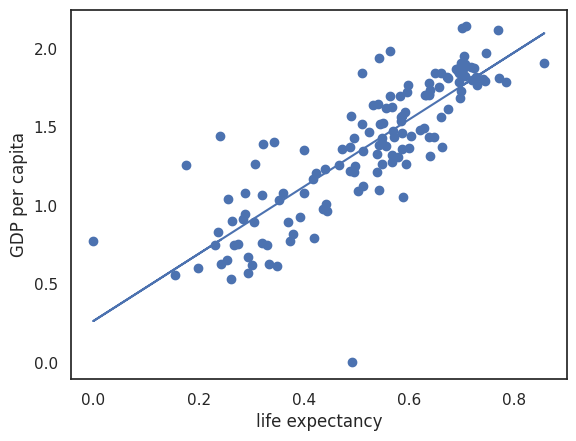

In [121]:
from scipy import stats

x = data["Healthy life expectancy"]
y = data["Log GDP per capita"]

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
 return slope * x + intercept

mymodel = list(map(myfunc, x))

plt.scatter(x, y)
plt.plot(x, slope * x + intercept)
plt.xlabel("life expectancy")
plt.ylabel ("GDP per capita")
plt.show()


## Explanation

* Get important key values with: slope, intercept, r, p, std_err = stats.linregress(x, y)
* Create a function that uses the slope and intercept values to return a new value. This new value represents where on the y-axis the corresponding x value will be placed
* Run each value of the x array through the function. This will result in a new array with new values for the y-axis: mymodel = list(map(myfunc, x))
* Draw the original scatter plot: plt.scatter(x, y)
* Draw the line of linear regression: plt.plot(x, mymodel)
* Define maximum and minimum values of the axis
Label the axis: **"life expectancy"** and **"GDP per capita"**

*Let compare the prediction of one feature vs all the features performance on Healthy life expectancy prediction*

In [122]:
import statsmodels.formula.api as smf

model = smf.ols('Q("Healthy life expectancy") ~ Q("Log GDP per capita")', data=data)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                 
Dep. Variable:     Q("Healthy life expectancy")   R-squared:                       0.689
Model:                                      OLS   Adj. R-squared:                  0.687
Method:                           Least Squares   F-statistic:                     306.2
Date:                          Sun, 05 Apr 2026   Prob (F-statistic):           7.58e-37
Time:                                  00:01:25   Log-Likelihood:                 136.00
No. Observations:                           140   AIC:                            -268.0
Df Residuals:                               138   BIC:                            -262.1
Df Model:                                     1                                         
Covariance Type:                      nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------

**Coef** is short for coefficient. It is the output of the linear regression function.
The linear regression function can be rewritten mathematically as:

Healthy life expectancy = 0.3221 * Q("Log GDP per capita") + 0.0768
These numbers means:

* If ALog GDP per capita increases by 1, life expectancy increases by 0.3296 (or 0,3 rounded)
* If GDP per capita = 0, life expectancy is equal to 0.0768 (or 0.08 rounded).
* Remember that the intercept is used to adjust the model's precision of predicting!
* we have p value of 0.004
* Rsquare of 69%
  
I don't think that this is a good model, but let's go on with this thought?

## Hypothesis Testing and P-value

The null hypothesis can either be rejected or not.

If we reject the null hypothesis, we conclude that it exist a relationship between Log GDP per capita and life expectancy. The P-value is used for this conclusion.

A common threshold of the P-value is 0.05.

Note: A P-value of 0.05 means that 5% of the times, we will falsely reject the null hypothesis. It means that we accept that 5% of the times, we might falsely have concluded a relationship.

If the P-value is lower than 0.05, we can reject the null hypothesis and conclude that it exist a relationship between the variables.

However, the P-value of Log GDP per capita is 0.004. So, we conclude a relationship between Log GDP per capita and life expectancy.

It means that there is a 0.4% chance that the true coefficient of Log GDP per capita is zero.

The intercept is used to adjust the regression function's ability to predict more precisely. It is therefore uncommon to interpret the P-value of the intercept.

R-Squared value of 69%, which means that the linear regression function line does fit the data well.

## Let define the linear regression function in Python to perform predictions.

What is life expectancy if Log GDP per capita is: 0.5, 0.8, 1.2, 1.5, 1.7?

In [123]:
def Predict_life_expectancy(LogGDPpercapita):
 return(0.3221 *  LogGDPpercapita  + 0.0768)
 
#Try some different values:
print(Predict_life_expectancy(0.5))
print(Predict_life_expectancy(0.8))
print(Predict_life_expectancy(1.2))
print(Predict_life_expectancy(1.5))
print(Predict_life_expectancy(1.7))

0.23785
0.33448
0.46331999999999995
0.55995
0.62437


## What realy contries to a long life expectancy

In [124]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

X = data.drop(["Country name","Healthy life expectancy"], axis=1)
y = data["Healthy life expectancy"]
#train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.4, random_state=42)
# LinearRegression Model
Lr = LinearRegression()
Lr.fit(X_train, y_train)

# Assuming lr is your fitted linear regression model and X is your feature DataFrame
coef = Lr.coef_  # Get the coefficients from the linear regression model
column = X.columns  # Get the feature names

# Create a DataFrame with feature names and their corresponding coefficients
df_ = pd.DataFrame({'Feature': column, 'Coefficient': coef})

# Reset the index if needed (not necessary here since we are creating a new DataFrame)
df_ = df_.reset_index(drop=True)

# Display the DataFrame
print(df_)

                        Feature  Coefficient
0            Regional indicator     0.000043
1                  Ladder score     0.455424
2                  upperwhisker     0.274530
3                  lowerwhisker     0.269299
4            Log GDP per capita    -0.998283
5                Social support    -1.000012
6  Freedom to make life choices    -0.999392
7                    Generosity    -0.996799
8     Perceptions of corruption    -1.000615
9           Dystopia + residual    -0.999133


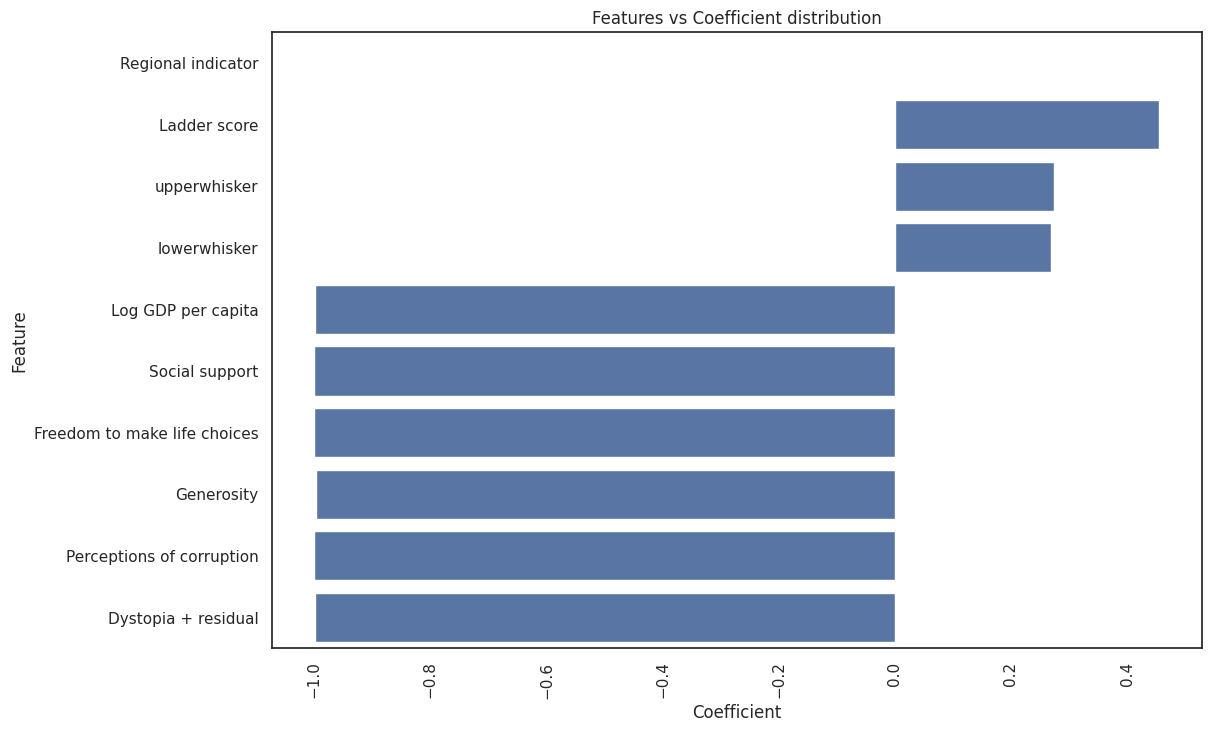

In [125]:
plt.figure(figsize=(12,8))
sns.barplot(data= df_, x="Coefficient", y="Feature")
plt.title('Features vs Coefficient distribution')
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.xticks(rotation=90)
plt.show()

## Model evaluation and prediction

In [126]:
y_pred = Lr.predict(X_test)
#r2_score
linear_score = metrics.r2_score(y_test, y_pred)

def Evaluation(x_test, y_test, model) :
  y_pred = model.predict(x_test)
  mse = metrics.mean_absolute_error(y_test, y_pred)
  msqe = metrics.mean_squared_error(y_test, y_pred)
  r2_score = metrics.r2_score(y_test, y_pred)
  rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

  print("mean_absolute_error : ", mse)
  print("mean_squared_error : ", msqe)
  print("root_mean_absolute_error : ", rmse)
  print("r2_score    : ", r2_score)
#Evalution 
Evaluation(X_test, y_test, Lr)

mean_absolute_error :  0.0007196623343124793
mean_squared_error :  8.22734523816031e-07
root_mean_absolute_error :  0.0009070471453105571
r2_score    :  0.9999674782775639


## Compare the model prediction

In [127]:
def compare(y_test, y_pred) :
  compare = pd.DataFrame()
  compare["Actual life expectancy"] = y_test
  compare["Predict"] = y_pred

  return compare
    
compare(y_test, y_pred)

,Actual life expectancy,Predict
111,0.330,0.330643
68,0.511,0.510012
31,0.583,0.582041
122,0.333,0.335192
42,0.542,0.543726
12,0.661,0.659622
82,0.322,0.322331
70,0.542,0.542836
107,0.321,0.321625
112,0.199,0.199830
